In [31]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import cv2

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.v2 as v2
from torchvision import models
import torch.nn as nn
from torchmetrics import Metric

In [32]:
# # https://drive.google.com/file/d/16QCd2dhOGNNDFxTFzLFmBG9SzP06A-y5/view
# !gdown 16QCd2dhOGNNDFxTFzLFmBG9SzP06A-y5
# !unzip ./data.zip

In [33]:
seed = 43
torch.random.manual_seed(seed)
np.random.seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
root_path = "/home/stefan/ioai-prep/kits/roai-2025/angry-birds"

batch_size = 64

In [34]:
weights = models.ResNet50_Weights.IMAGENET1K_V1
resnet = models.resnet50(weights=weights).to(device)
resnet.fc = nn.Identity()
resnet.eval()
print("model loaded.")

model loaded.


# Data preparation

In [35]:
def detect_background(img_path):
    # high blue channel saturation usually means Water
    img = cv2.imread(img_path) # BGR
    blue_mean = img[:, :, 0].mean() / 255.0
    return 1 if blue_mean > 0.5 else 0

In [36]:
class AngryBirdsDataset(Dataset):
    def __init__(self, mode="train"):
        super().__init__()
        self.mode = mode
        self.dir = f"{root_path}/{'train' if mode == 'train' else 'test'}_data"
        self.df = pd.read_csv(f"{self.dir}/{mode}.csv")

        self.transforms = v2.Compose([
            v2.CenterCrop(224 - 24),
            v2.Resize(224),
            
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        if self.mode in ["train", "val"]:
            tqdm.pandas(desc=f"Labeling {mode}")
            # Group: 0:Earth/Land, 1:Earth/Water, 2:Water/Land, 3:Water/Water
            self.df["bg"] = self.df["filename"].progress_apply(
                lambda x: detect_background(f"{self.dir}/{self.mode}/{x}")
            )
            self.df["y_4way"] = self.df["y"] * 2 + self.df["bg"]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = f"{self.dir}/{self.mode}/{row['filename']}"
        pt_path = f"{filename}.pt"

        if not os.path.exists(pt_path):
            img_pil = Image.open(filename)
            img_t = self.transforms(img_pil).unsqueeze(0).to(device)
            with torch.no_grad():
                embd = resnet(img_t).squeeze(0).cpu()
            torch.save(embd, pt_path)
        else:
            embd = torch.load(pt_path, map_location="cpu")

        if self.mode in ["train", "val"]:
            return embd, torch.tensor(row["y_4way"], dtype=torch.long)
        return embd

    def __len__(self):
        return len(self.df)

In [37]:
train_ds = AngryBirdsDataset(mode="train")
val_ds = AngryBirdsDataset(mode="val")
test_ds = AngryBirdsDataset(mode="test")

y_train = train_ds.df["y_4way"].values
counts = np.bincount(y_train)
weights_map = 1.0 / counts
samples_weight = torch.from_numpy(weights_map[y_train])
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Labeling val: 100%|██████████| 1199/1199 [00:00<00:00, 3678.95it/s]


<Axes: >

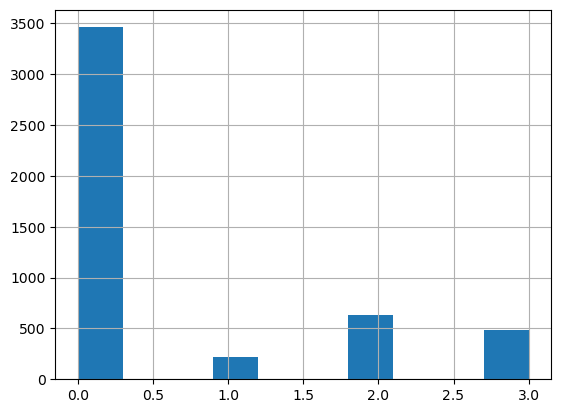

In [38]:
train_ds.df["y_4way"].hist()

# Model

In [39]:
class BirdsNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.head = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(2048, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.head(x)

In [40]:
model = BirdsNet().to(device)

# Training

In [41]:
class WorstClassAccuracy(Metric):
    def __init__(self):
        super().__init__()
        self.add_state("tp", default=torch.zeros(4), dist_reduce_fx="sum")
        self.add_state("total", default=torch.zeros(4), dist_reduce_fx="sum")

    def update(self, logits, y_4way):
        preds = torch.argmax(logits, dim=1)
        binary_target = y_4way // 2
        for g in range(4):
            mask = y_4way == g
            if mask.any():
                self.tp[g] += (preds[mask] == binary_target[mask]).sum()
                self.total[g] += mask.sum()

    def compute(self):
        accs = self.tp / (self.total + 1e-6)
        return torch.min(accs)

In [42]:
class RobustLoss(nn.Module):
    def __init__(self, irm_lambda=0.0, dro_eta=0.01):
        super().__init__()
        self.irm_lambda = irm_lambda
        self.dro_eta = dro_eta
        self.register_buffer("q", torch.ones(4) / 4)  # Group weights for DRO

    def irm_penalty(self, logits, y):
        scale = torch.tensor(1.0).to(logits.device).requires_grad_(True)
        loss = F.cross_entropy(logits * scale, y)
        grad = torch.autograd.grad(loss, [scale], create_graph=True)[0]
        return torch.sum(grad**2)

    def forward(self, logits, y_4way):
        # y is 4-way, but we predict binary classes (0,1) from the model
        # the model output 2 units
        binary_labels = y_4way // 2

        per_sample_losses = F.cross_entropy(logits, binary_labels, reduction="none")

        group_losses = torch.zeros(4).to(logits.device)
        penalty = 0.0

        for g in range(4):
            mask = y_4way == g
            if mask.any():
                group_losses[g] = per_sample_losses[mask].mean()
                penalty += self.irm_penalty(logits[mask], binary_labels[mask])

        # DRO update
        self.q = self.q * torch.exp(group_losses.detach() * self.dro_eta)
        self.q /= self.q.sum()

        dro_loss = torch.sum(self.q * group_losses)
        return dro_loss + self.irm_lambda * penalty

In [43]:
epochs = 60
lr = 5e-6

criterion = RobustLoss(irm_lambda=0.5, dro_eta=0.01).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=20, factor=0.5)

accuracy_metric = WorstClassAccuracy().to(device)
best_acc = float("-inf")

In [44]:
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0
    for embd, y_4way in tqdm(train_loader, desc=f"Epoch {epoch}"):
        embd, y_4way = embd.to(device), y_4way.to(device)

        logits = model(embd)
        loss = criterion(logits, y_4way)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    accuracy_metric.reset()
    with torch.no_grad():
        for embd, y_4way in val_loader:
            embd, y_4way = embd.to(device), y_4way.to(device)
            logits = model(embd)
            accuracy_metric.update(logits, y_4way)

    val_acc = accuracy_metric.compute()
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best.pth")
    scheduler.step(val_acc)

    print(
        f"Epoch {epoch}: Loss={train_loss/len(train_loader):.4f}, Worst-Group Acc={val_acc*100:.2f}%"
    )

Epoch 1: 100%|██████████| 75/75 [00:02<00:00, 36.89it/s]


Epoch 1: Loss=0.8693, Worst-Group Acc=7.66%


Epoch 2: 100%|██████████| 75/75 [00:02<00:00, 37.01it/s]


Epoch 2: Loss=0.8335, Worst-Group Acc=13.40%


Epoch 3: 100%|██████████| 75/75 [00:02<00:00, 30.53it/s]


...

Epoch 58: Loss=0.3280, Worst-Group Acc=81.25%


Epoch 59: 100%|██████████| 75/75 [00:01<00:00, 38.06it/s]


Epoch 59: Loss=0.3271, Worst-Group Acc=81.25%


Epoch 60: 100%|██████████| 75/75 [00:02<00:00, 37.34it/s]


Epoch 60: Loss=0.3352, Worst-Group Acc=82.81%


In [45]:
model.load_state_dict(torch.load("best.pth"))

<All keys matched successfully>

# Submission

In [46]:
df_test = pd.read_csv(f"{root_path}/test_data/test.csv")

In [47]:
answers = []
model.eval()

for embd in tqdm(test_loader):
    embd = embd.to(device)
    with torch.no_grad():
        logits = model(embd)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        answers.extend(preds)

100%|██████████| 110/110 [00:02<00:00, 40.06it/s]


In [48]:
pd.Series(answers).value_counts()

0    5006
1    1987
Name: count, dtype: int64

In [49]:
submission = pd.DataFrame({
    "datapointID": df_test["datapointID"],
    "subtaskID": 1,
    "answer": answers
})

submission.head()

,datapointID,subtaskID,answer
0,0,1,0
1,1,1,0
2,2,1,0
3,3,1,0
4,4,1,0


In [50]:
submission.to_csv(f"{root_path}/submission.csv", index=False)